**Import Libraries**

In [25]:
import pandas as pd
import numpy as np
import re
import string
import nltk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import pickle
import os

In [3]:
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Load Datasets**

In [4]:
df1 = pd.read_csv("../data/Fake_Real_Data.csv")           # Fake_Real_Data dataset
df2 = pd.read_csv("../data/IFND.csv")                     # IFND dataset
df3 = pd.read_csv('../data/WELFake_Dataset.csv')          # WELFake dataset

In [ ]:
df1.head()     # Fake_Real_Data dataset

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [6]:
df2.head()      # IFND dataset

,Unnamed: 0,Statement,Image,Label
0,0,"WHO praises India's Aarogya Setu app, says it ...",https://cdn.dnaindia.com/sites/default/files/s...,true
1,1,"In Delhi, Deputy US Secretary of State Stephen...",https://cdn.dnaindia.com/sites/default/files/s...,true
2,2,LAC tensions: China's strategy behind delibera...,https://cdn.dnaindia.com/sites/default/files/s...,true
3,3,India has signed 250 documents on Space cooper...,https://cdn.dnaindia.com/sites/default/files/s...,true
4,4,Tamil Nadu chief minister's mother passes away...,https://cdn.dnaindia.com/sites/default/files/s...,true


In [7]:
df3.head()    # WELFake dataset

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


**Renaming columns to have consistency**

In [8]:
df1 = df1.rename(columns={'Text': 'text', 'label': 'label'})
df2 = df2.rename(columns={'Statement': 'text', 'Label': 'label'})
df3['text'] = df3['title'] + ' ' + df3['text']


**Dropping Unwanted Columns**

In [9]:
df2.drop(columns=["Unnamed: 0","Image"], inplace=True)
df3.drop(columns=["Unnamed: 0","title"], inplace=True)

In [10]:
df1.head()

,text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [11]:
df2.head()

,text,label
0,"WHO praises India's Aarogya Setu app, says it ...",true
1,"In Delhi, Deputy US Secretary of State Stephen...",true
2,LAC tensions: China's strategy behind delibera...,true
3,India has signed 250 documents on Space cooper...,true
4,Tamil Nadu chief minister's mother passes away...,true


In [12]:
df3.head()

,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
1,NaN,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1


**Standardize Labels (0 = REAL, 1 = FAKE)**

In [13]:
def normalize_label(x):
    if str(x).lower() == 'fake' or str(x) == 1:
        return 1
    else:
        return 0

In [14]:
df1['label'] = df1['label'].apply(normalize_label)
df2['label'] = df2['label'].apply(normalize_label)
df3['label'] = df3['label'].apply(normalize_label)

Adding Source name for each dataset

In [15]:
df1['source'] = 'Fake_Real_Data'
df2['source'] = 'IFND'
df3['source'] = 'WELFake'

**Combining All Datasets**

In [17]:
data = pd.concat([df1[['text', 'label', 'source']],
                  df2[['text', 'label', 'source']],
                  df3[['text', 'label', 'source']]], ignore_index=True)

print("Total combined data:", data.shape)
data.head()

Total combined data: (138282, 3)


,text,label,source
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,1,Fake_Real_Data
1,U.S. conservative leader optimistic of common ...,0,Fake_Real_Data
2,"Trump proposes U.S. tax overhaul, stirs concer...",0,Fake_Real_Data
3,Court Forces Ohio To Allow Millions Of Illega...,1,Fake_Real_Data
4,Democrats say Trump agrees to work on immigrat...,0,Fake_Real_Data


**Text Cleaning** 

In [18]:
stop_words = stopwords.words('english')

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = ' '.join([word for word in text.split() if word not in stop_words])
    return text


In [19]:
data['text'] = data['text'].apply(clean_text)

**Train Test Split**

20% Testing Data  
80% Training Data

In [20]:
X = data['text']
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True)

**Vectorization**

In [21]:
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)


**Model Training**

Logistic Regression

In [22]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=2000)

**Model Evaluation**

In [23]:
y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.914271251401092

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.98      0.95     22966
           1       0.85      0.60      0.70      4691

    accuracy                           0.91     27657
   macro avg       0.89      0.79      0.83     27657
weighted avg       0.91      0.91      0.91     27657



**Confusion Matrix**

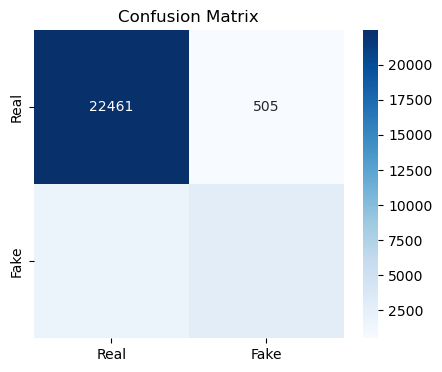

In [26]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title("Confusion Matrix")
plt.show()

**Save the Model and Vectorizer**

Create a folder named 'model' if it doesn't exist

In [28]:
os.makedirs('../model', exist_ok=True)

In [29]:
with open('../model/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../model/vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)